# EHA Clinics â€” Procurement Data Quality & Overview

**Purpose:** Characterise the procurement dataset before modelling â€” coverage by facility and category, temporal completeness, null-value profile, and demand intermittency per category-facility pair.

**Dataset:** `data/Clinics Procurement Data.csv`

**Key context:**
- Records with no `branch_name` (2018â€“2021) reflect the single-branch operating period â€” retained for context but outside the Jan 2021â€“Dec 2023 modelling window.
- The Kano â€“ Independence Road Sep 2021 bulk stock-load (365 lines, ~258 k units) is excluded from the modelling window.
- Laboratory Consumables carry the highest unit-cost risk.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

try:
    import xgboost as xgb
except ImportError:
    raise ImportError('XGBoost not found.\nInstall with: pip install xgboost')

try:
    import lightgbm as lgb
except ImportError:
    raise ImportError('LightGBM not found.\nInstall with: pip install lightgbm')

from sklearn.ensemble import RandomForestRegressor

try:
    from prophet import Prophet
except ImportError:
    raise ImportError('Prophet not found.\nInstall with: pip install prophet')

from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'grid.linestyle':     '--',
    'figure.dpi':         130,
    'axes.titlesize':     11,
    'axes.titleweight':   'bold',
})

BLUE, GREEN, RED, AMBER = '#00548E', '#009976', '#C0392B', '#E67E22'
MODEL_COLOURS = {
    'XGBoost':       BLUE,
    'LightGBM':      GREEN,
    'Random Forest': AMBER,
}

print('All imports OK.')

All imports OK.


In [2]:
# â”€â”€ Project root resolution â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
PROJECT_ROOT = Path().resolve()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / 'data').exists(), f'Cannot find data/ under {PROJECT_ROOT}'

DATA_DIR    = PROJECT_ROOT / 'data'
REPORTS_DIR = PROJECT_ROOT / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

# â”€â”€ Display name helpers â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
SHORT_NAMES = {
    'Asba & Dantata, Abuja':           'Asba (Abuja)',
    'Abuja - Asba and Dantata':        'Asba (Abuja)',
    'Abuja - Lugbe':                   'Lugbe (Abuja)',
    'Kano - Lamido Crescent':          'Lamido (Kano)',
    'Kano - Independence Road':        'Indep. Rd (Kano)',
    'Lagos - Sangotedo Ajah':          'Sangotedo (Lagos)',
    'Lagos- Sangotedo Ajah':           'Sangotedo (Lagos)',
    'REACH Abuja Hub 1 Clinic - Kuje': 'REACH Kuje',
}

SHORT_CATS = {
    'Prescription Medications': 'Rx Meds',
    'Over The Counter Drugs':   'OTC Drugs',
    'Medical Consumables':      'Med. Consumables',
    'Laboratory Consumables':   'Lab Consumables',
    'Consumables':              'Consumables',
    'Injections':               'Injections',
    'Vaccines':                 'Vaccines',
    'NPI Vaccines':             'NPI Vaccines',
    'Dental Consumables':       'Dental Consumables',
}

HIGH_RISK_CATS = {'Laboratory Consumables'}

# â”€â”€ Time windows â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
TRAIN_START = pd.Timestamp('2021-01-01')
TRAIN_END   = pd.Timestamp('2023-12-01')
VAL_START   = pd.Timestamp('2024-01-01')
VAL_END     = pd.Timestamp('2024-06-01')
H           = 6

CV_FOLDS = [
    (pd.Timestamp('2021-01-01'), pd.Timestamp('2022-12-01'),
     pd.Timestamp('2023-01-01'), pd.Timestamp('2023-06-01')),
    (pd.Timestamp('2021-01-01'), pd.Timestamp('2023-06-01'),
     pd.Timestamp('2023-07-01'), pd.Timestamp('2023-12-01')),
]

# â”€â”€ Nigerian Eid dates (snapped to month-start for monthly series) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
EID_FITR_MONTHS = {
    pd.Timestamp(d).to_period('M').to_timestamp()
    for d in ['2021-05-13', '2022-05-02', '2023-04-21', '2024-04-10']
}
EID_ADHA_MONTHS = {
    pd.Timestamp(d).to_period('M').to_timestamp()
    for d in ['2021-07-20', '2022-07-09', '2023-06-28', '2024-06-16']
}

print(f'Project root : {PROJECT_ROOT}')
print(f'Data dir     : {DATA_DIR}')

Project root : C:\Users\joshua.ogundairo\Desktop\Clinics\Procurement Predictive Modeling
Data dir     : C:\Users\joshua.ogundairo\Desktop\Clinics\Procurement Predictive Modeling\data


## 1. Data Loading

In [3]:
print("Loading data...")
df_raw = pd.read_csv(DATA_DIR / "Clinics Procurement Data-1778233381741.csv", low_memory=False)

# harmonise column names to match downstream code
df_raw = df_raw.rename(columns={
    "product_uom_qty":   "product_qty",
    "product_category":  "category_name",
    "requesting_branch": "branch_name",
})

df_raw["date_order"]     = pd.to_datetime(df_raw["date_order"],    errors="coerce")
df_raw["month"]          = df_raw["date_order"].dt.to_period("M").dt.to_timestamp()
df_raw["year"]           = df_raw["date_order"].dt.year
df_raw["product_qty"]    = pd.to_numeric(df_raw["product_qty"],    errors="coerce").fillna(0)
df_raw["price_subtotal"] = pd.to_numeric(df_raw["price_subtotal"], errors="coerce").fillna(0)

df = df_raw[
    (df_raw["state"] == "done") &
    (df_raw["product_qty"] > 0) &
    (df_raw["price_subtotal"] >= 0)
].copy()

bulk_mask  = (df["branch_name"] == "Kano - Independence Road") & (df["year"] == 2021)
n_excluded = bulk_mask.sum()
df = df[~bulk_mask].copy()

df["branch_short"] = df["branch_name"].apply(
    lambda x: SHORT_NAMES.get(x, str(x)) if pd.notna(x) else "Pre-Branch Era"
)
df["cat_short"]    = df["category_name"].apply(lambda x: SHORT_CATS.get(x, str(x)))

print(f"  Loaded records    : {len(df):,}  (excluded {n_excluded:,} Kano Indep. Rd 2021 bulk rows)")
print(f"  Facilities        : {df['branch_name'].nunique()}")
print(f"  Categories        : {df['category_name'].nunique()}")
print(f"  Date range        : {df['month'].min().date()} to {df['month'].max().date()}")


Loading data...
  Loaded records    : 30,515  (excluded 495 Kano Indep. Rd 2021 bulk rows)
  Facilities        : 15
  Categories        : 38
  Date range        : 2018-09-01 to 2026-05-01


In [4]:
# â”€â”€ Monthly aggregation with zero-fill â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
monthly_raw = (
    df.groupby(['category_name', 'branch_name', 'month'])['product_qty']
    .sum().reset_index()
)

full_index = pd.date_range(TRAIN_START, VAL_END, freq='MS')
all_pairs  = monthly_raw[['category_name', 'branch_name']].drop_duplicates()

records = []
for _, row in all_pairs.iterrows():
    sub = (
        monthly_raw[
            (monthly_raw['category_name'] == row['category_name']) &
            (monthly_raw['branch_name']   == row['branch_name'])
        ]
        .set_index('month')['product_qty']
        .reindex(full_index, fill_value=0)
    )
    sub.index.name = 'month'
    sub = sub.reset_index()
    sub['category_name'] = row['category_name']
    sub['branch_name']   = row['branch_name']
    records.append(sub)

df_monthly = pd.concat(records, ignore_index=True)
df_monthly['branch_short'] = df_monthly['branch_name'].apply(
    lambda x: SHORT_NAMES.get(x, str(x)) if pd.notna(x) else 'Pre-Branch Era'
)
df_monthly['cat_short']    = df_monthly['category_name'].apply(lambda x: SHORT_CATS.get(x, str(x)))

# â”€â”€ Train / validation split & pair readiness â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
df_train = df_monthly[df_monthly['month'].between(TRAIN_START, TRAIN_END)].copy()
df_val   = df_monthly[df_monthly['month'].between(VAL_START,   VAL_END  )].copy()

nz_months = (
    df_train[df_train['product_qty'] > 0]
    .groupby(['category_name', 'branch_name'])['month']
    .nunique().reset_index()
    .rename(columns={'month': 'nz_months'})
)

def classify(n):
    if n >= 24: return 'A'
    if n >= 12: return 'B'
    return 'C'

nz_months['readiness']    = nz_months['nz_months'].apply(classify)
nz_months['branch_short'] = nz_months['branch_name'].apply(
    lambda x: SHORT_NAMES.get(x, str(x)) if pd.notna(x) else 'Pre-Branch Era'
)
nz_months['cat_short'] = nz_months['category_name'].apply(
    lambda x: SHORT_CATS.get(x, str(x))
)
nz_months['high_risk']    = nz_months['category_name'].isin(HIGH_RISK_CATS)

eligible = nz_months[nz_months['readiness'].isin(['A', 'B'])].copy()
tier_c   = nz_months[nz_months['readiness'] == 'C'].copy()

print(f'Monthly series: {len(df_monthly):,} rows | {len(all_pairs)} pairs | {len(full_index)} months')
print(f'Tier A (>=24 months) : {(nz_months["readiness"]=="A").sum():>3} pairs')
print(f'Tier B (12-23 months): {(nz_months["readiness"]=="B").sum():>3} pairs')
print(f'Tier C (<12 months)  : {(nz_months["readiness"]=="C").sum():>3} pairs')
print(f'\nTotal eligible pairs for modelling: {len(eligible)}')

Monthly series: 9,744 rows | 232 pairs | 42 months
Tier A (>=24 months) :  16 pairs
Tier B (12-23 months):  16 pairs
Tier C (<12 months)  : 129 pairs

Total eligible pairs for modelling: 32


## 2. Data Overview & Quality Assessment

Record counts, facility coverage, missing-value profile, annual volume trend, demand intermittency, and monthly demand distributions.


In [5]:
# â”€â”€ Dataset overview â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print('=' * 60)
print('  DATASET OVERVIEW')
print('=' * 60)
print(f'  Raw records in CSV        : {len(df_raw):,}')
print(f'  Clean records (done+qty>0): {len(df):,}')
print(f'  Date range                : {df["month"].min().date()}  to  {df["month"].max().date()}')
print(f'  Unique facilities         : {df["branch_name"].nunique()}')
print(f'  Unique categories         : {df["category_name"].nunique()}')
null_branch = df_raw['branch_name'].isnull().sum() if 'branch_name' in df_raw.columns else 0
print(f'  Null branch_name (pre-branch era): {null_branch:,} raw records')
print()
print('  State breakdown (all raw records):')
for state, cnt in df_raw['state'].value_counts(dropna=False).items():
    print(f'    {str(state):<20} {cnt:>7,}  ({cnt/len(df_raw)*100:.1f}%)')
print()
print('  Records by facility (clean):')
for fac, cnt in df['branch_name'].value_counts(dropna=False).items():
    label = SHORT_NAMES.get(fac, str(fac)) if pd.notna(fac) else 'Pre-Branch Era'
    print(f'    {label:<28} {cnt:>6,}')
print()
print('  Records by category (clean):')
for cat, cnt in df['category_name'].value_counts().items():
    label = SHORT_CATS.get(cat, cat)
    print(f'    {label:<24} {cnt:>6,}')


  DATASET OVERVIEW
  Raw records in CSV        : 34,300
  Clean records (done+qty>0): 30,515
  Date range                : 2018-09-01  to  2026-05-01
  Unique facilities         : 15
  Unique categories         : 38
  Null branch_name (pre-branch era): 4,066 raw records

  State breakdown (all raw records):
    done                  31,798  (92.7%)
    purchase               2,502  (7.3%)

  Records by facility (clean):
    Lamido (Kano)                 8,943
    Asba (Abuja)                  8,841
    Kano Distribution Warehouse   3,505
    Pre-Branch Era                3,096
    Sangotedo (Lagos)             1,980
    Lugbe (Abuja)                 1,184
    REACH Kuje                    1,124
    REACH Kano Hub 1 Clinic - Gyadi-Gyadi    820
    Lagos - Pan Atlantic University    375
    eDokta-Tofa                     212
    Indep. Rd (Kano)                203
    NSPM-Abuja 1                    180
    NSPM-Abuja 2                     23
    EHA Clinics                      21
    

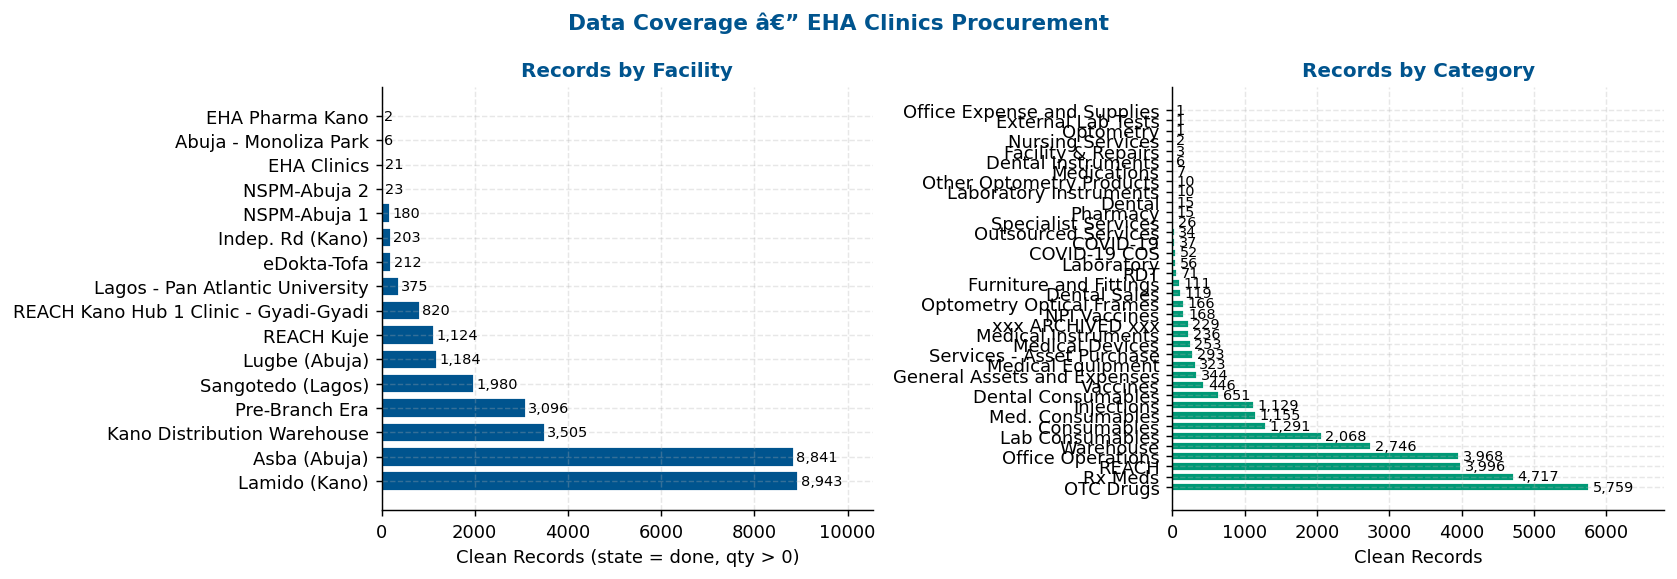

In [6]:
# â”€â”€ Coverage visualisation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

fac_counts = df['branch_name'].value_counts(dropna=False)
fac_labels = [SHORT_NAMES.get(f, str(f)) if pd.notna(f) else 'Pre-Branch Era'
              for f in fac_counts.index]
bars = axes[0].barh(fac_labels, fac_counts.values, color=BLUE, edgecolor='white')
for bar, v in zip(bars, fac_counts.values):
    axes[0].text(v + 50, bar.get_y() + bar.get_height() / 2,
                 f'{v:,}', va='center', fontsize=8)
axes[0].set_xlabel('Clean Records (state = done, qty > 0)')
axes[0].set_title('Records by Facility', color=BLUE)
axes[0].set_xlim(0, fac_counts.values.max() * 1.18)

cat_counts = df['category_name'].value_counts()
cat_labels = [SHORT_CATS.get(c, c) for c in cat_counts.index]
bars2 = axes[1].barh(cat_labels, cat_counts.values, color=GREEN, edgecolor='white')
for bar, v in zip(bars2, cat_counts.values):
    axes[1].text(v + 50, bar.get_y() + bar.get_height() / 2,
                 f'{v:,}', va='center', fontsize=8)
axes[1].set_xlabel('Clean Records')
axes[1].set_title('Records by Category', color=BLUE)
axes[1].set_xlim(0, cat_counts.values.max() * 1.18)

fig.suptitle('Data Coverage â€” EHA Clinics Procurement', fontsize=12,
             fontweight='bold', color=BLUE)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "figures" / "dq_coverage.pdf", bbox_inches="tight")
plt.show()


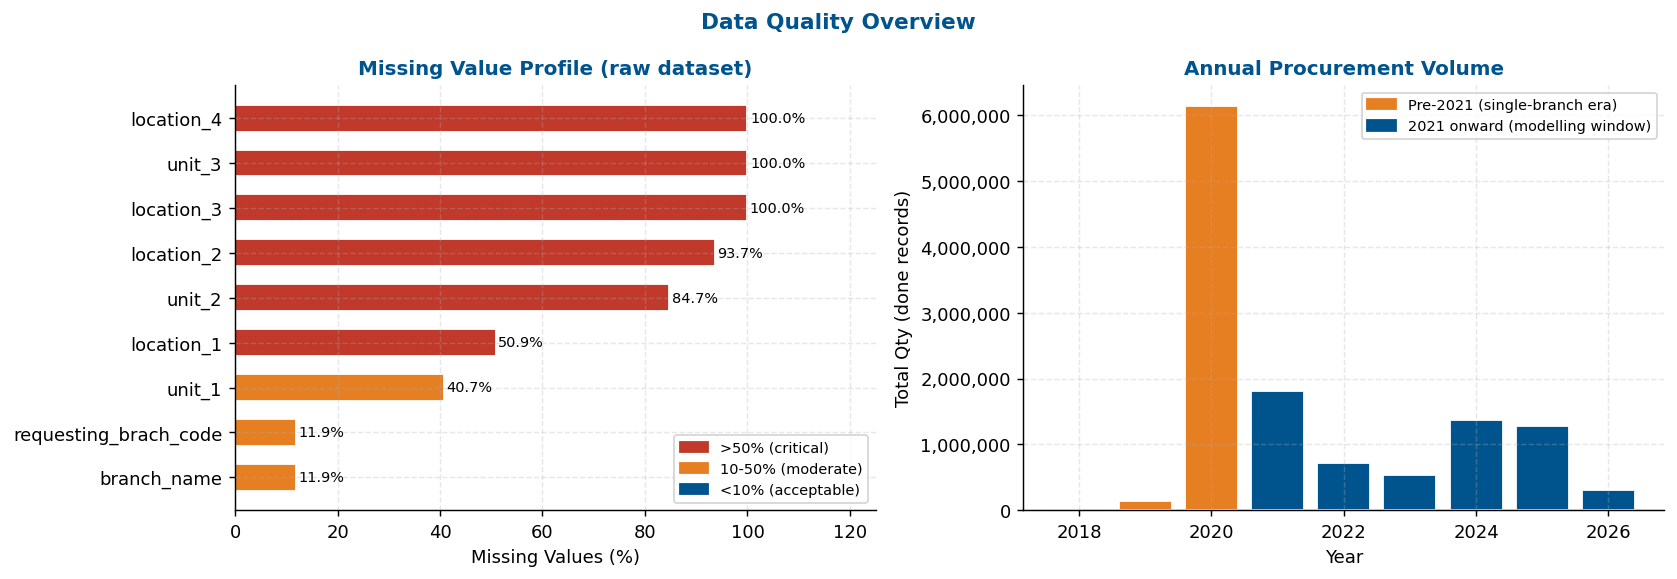

In [7]:
# â”€â”€ Missing-value profile + annual volume trend â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

miss     = df_raw.isnull().sum()
miss_pct = (miss / len(df_raw) * 100).sort_values(ascending=True)
miss_pct = miss_pct[miss_pct > 0]
bar_clrs = [RED if v > 50 else AMBER if v > 10 else BLUE for v in miss_pct.values]
bars_m = axes[0].barh(miss_pct.index, miss_pct.values, color=bar_clrs, edgecolor='white', height=0.6)
for bar, v in zip(bars_m, miss_pct.values):
    axes[0].text(v + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{v:.1f}%', va='center', fontsize=8)
axes[0].set_xlabel('Missing Values (%)')
axes[0].set_title('Missing Value Profile (raw dataset)', color=BLUE)
axes[0].set_xlim(0, miss_pct.values.max() * 1.25)
patches_m = [
    mpatches.Patch(color=RED,   label='>50% (critical)'),
    mpatches.Patch(color=AMBER, label='10-50% (moderate)'),
    mpatches.Patch(color=BLUE,  label='<10% (acceptable)'),
]
axes[0].legend(handles=patches_m, fontsize=8)

df_yr = df_raw.copy()
df_yr['year_num'] = pd.to_numeric(df_yr.get('year', pd.Series(dtype=float)), errors='coerce')
done_yr = (
    df_yr[df_yr['state'] == 'done']
    .groupby('year_num')['product_qty'].sum()
    .reset_index().dropna().sort_values('year_num')
)
done_yr['year_num'] = done_yr['year_num'].astype(int)
bar_yr = [AMBER if yr < 2021 else BLUE for yr in done_yr['year_num']]
axes[1].bar(done_yr['year_num'], done_yr['product_qty'], color=bar_yr, edgecolor='white')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Qty (done records)')
axes[1].set_title('Annual Procurement Volume', color=BLUE)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
patches_yr = [
    mpatches.Patch(color=AMBER, label='Pre-2021 (single-branch era)'),
    mpatches.Patch(color=BLUE,  label='2021 onward (modelling window)'),
]
axes[1].legend(handles=patches_yr, fontsize=8)

fig.suptitle('Data Quality Overview', fontsize=12, fontweight='bold', color=BLUE)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "figures" / "dq_missing_trend.pdf", bbox_inches="tight")
plt.show()


Pair readiness summary:
  A:  16 pairs  (>= 24 non-zero months â€” primary modelling)
  B:  16 pairs  (12-23 months â€” limited modelling)
  C: 129 pairs  (< 12 months â€” fixed-interval ordering recommended)


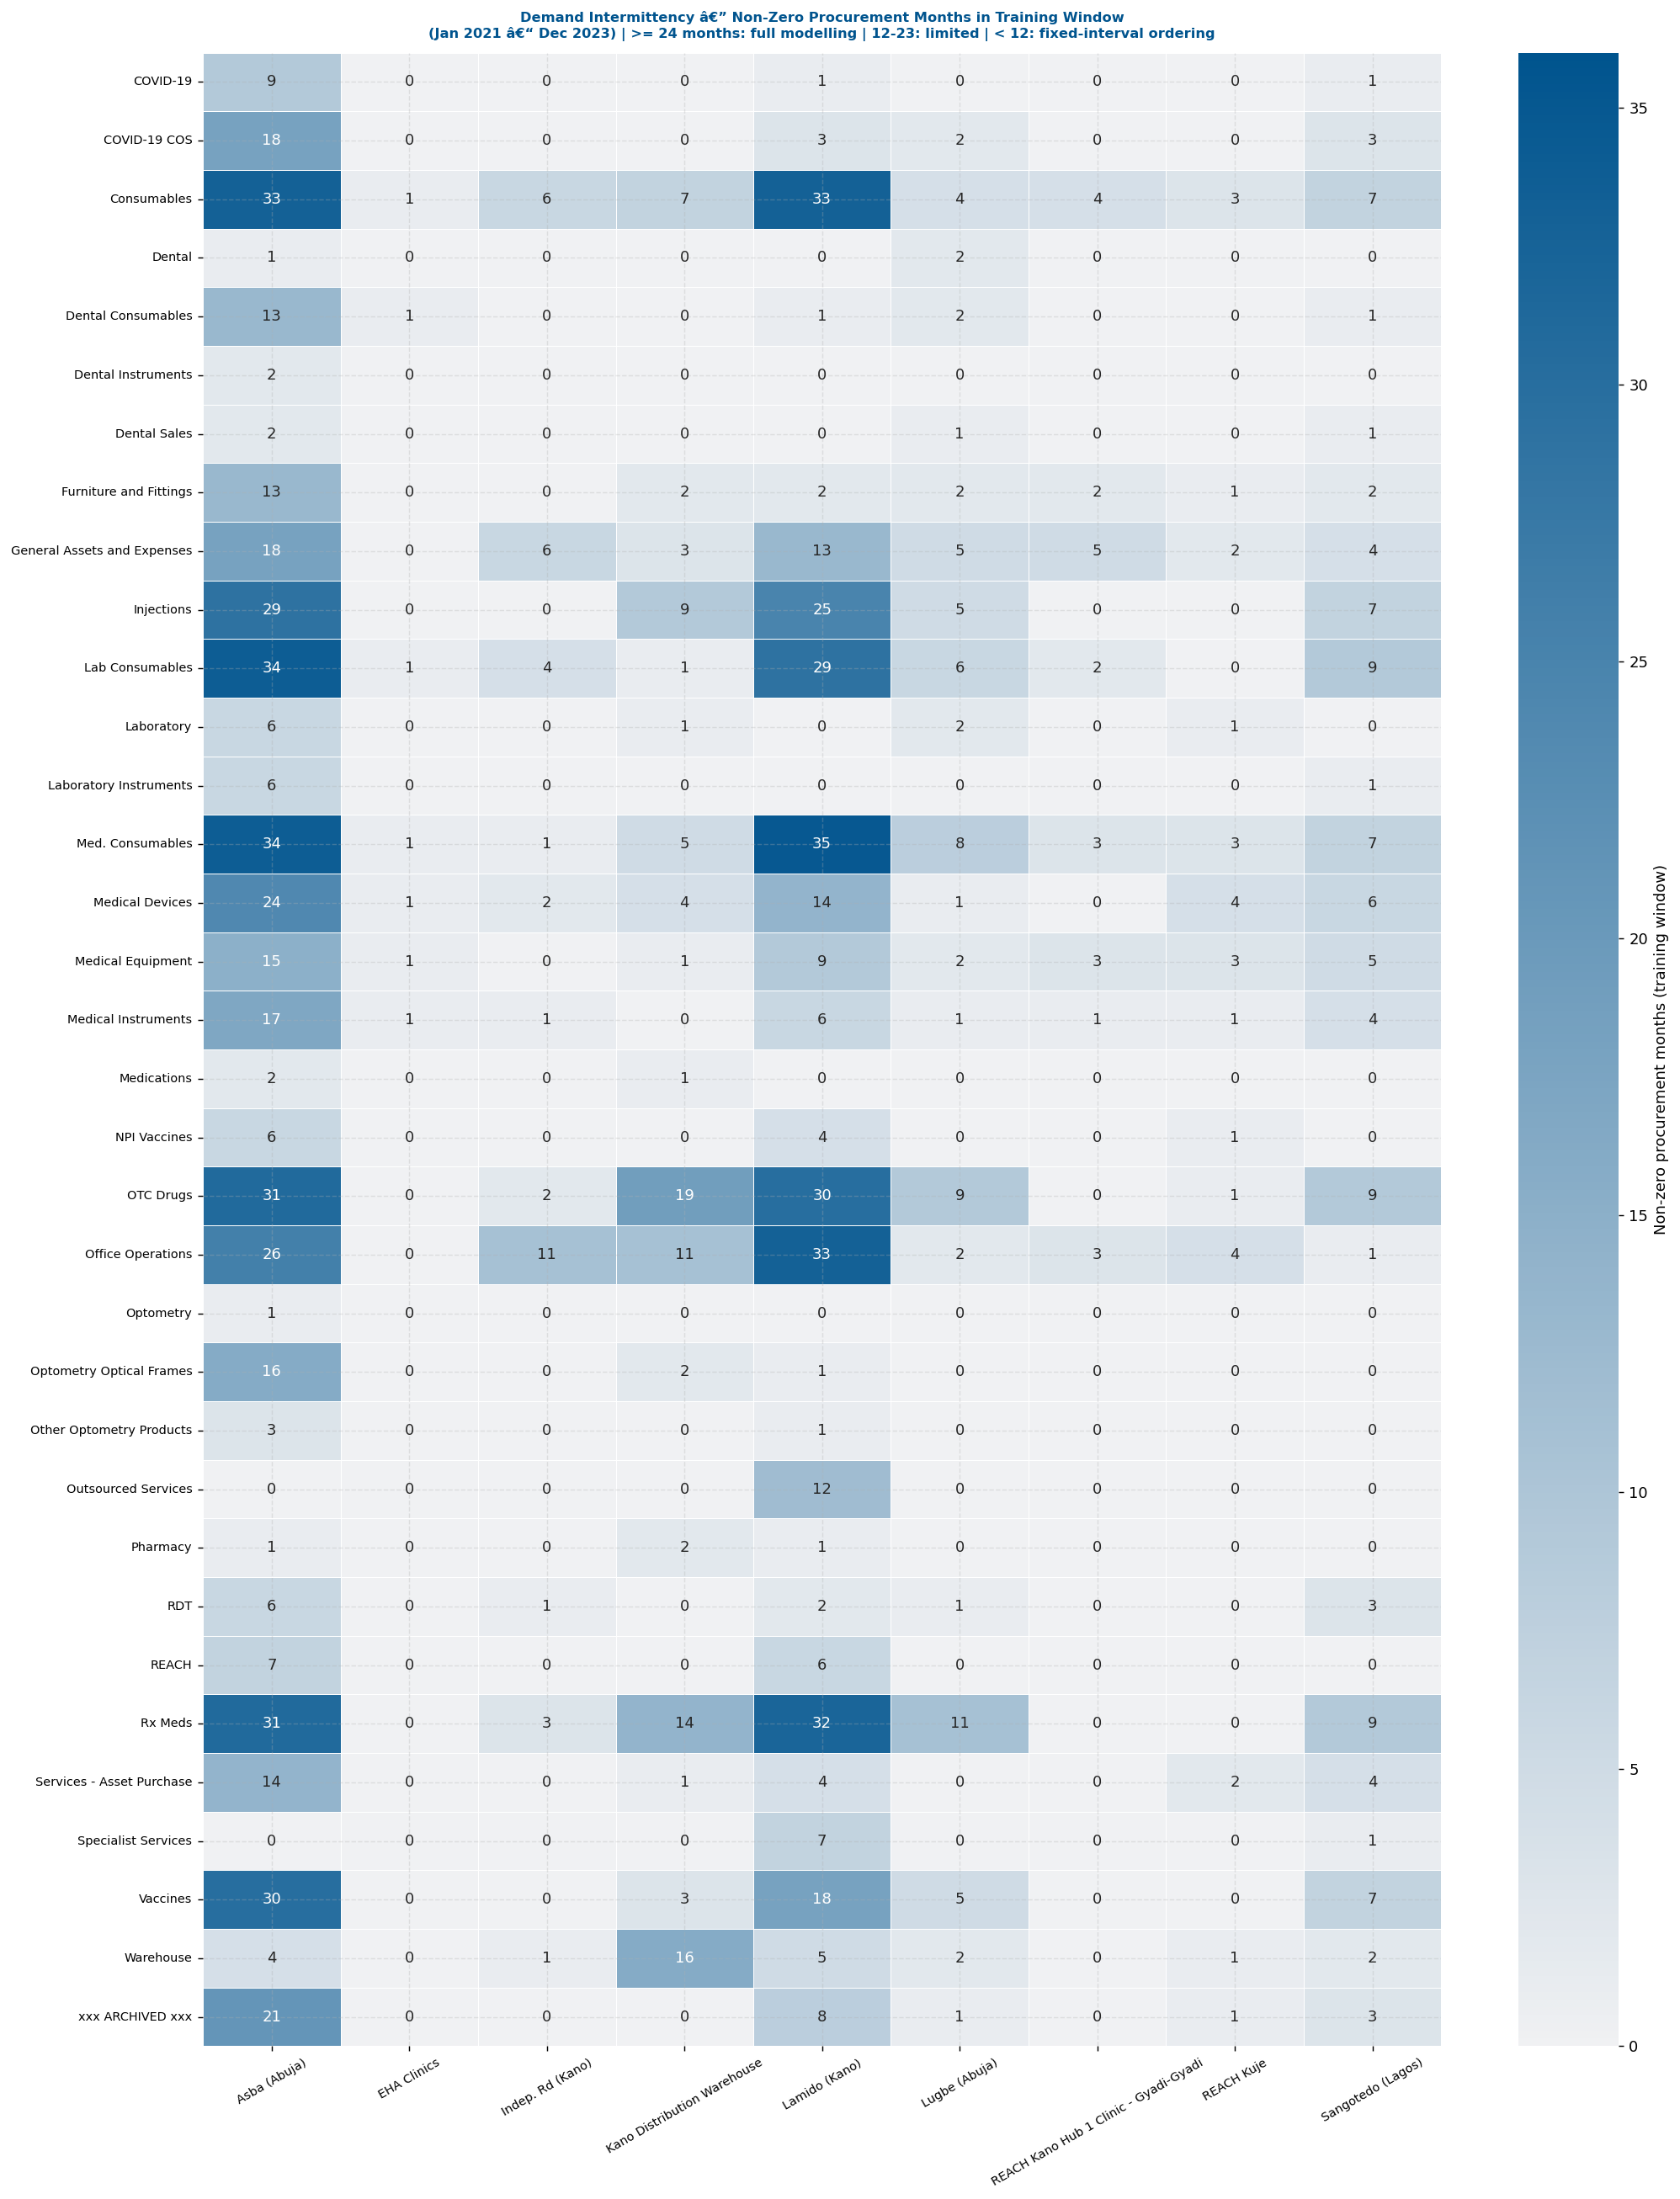

In [8]:
# â”€â”€ Demand intermittency heatmap â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# nz_months is built from the monthly aggregation above

pivot = nz_months.pivot_table(
    index='cat_short', columns='branch_short', values='nz_months', fill_value=0
)
pivot = pivot.reindex(columns=sorted(pivot.columns))

cmap = sns.light_palette(BLUE, as_cmap=True)

fig, ax = plt.subplots(
    figsize=(max(9, len(pivot.columns) * 1.8), max(4, len(pivot) * 0.55 + 1.5))
)
sns.heatmap(
    pivot, ax=ax,
    annot=True, fmt='.0f', cmap=cmap,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Non-zero procurement months (training window)'},
    vmin=0, vmax=36,
)
ax.set_title(
    'Demand Intermittency â€” Non-Zero Procurement Months in Training Window\n'
    '(Jan 2021 â€“ Dec 2023) | >= 24 months: full modelling | 12-23: limited | '
    '< 12: fixed-interval ordering',
    color=BLUE, fontsize=9, pad=10,
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)

print('Pair readiness summary:')
for tier, label in [('A', '>= 24 non-zero months â€” primary modelling'),
                    ('B', '12-23 months â€” limited modelling'),
                    ('C', '< 12 months â€” fixed-interval ordering recommended')]:
    count = (nz_months['readiness'] == tier).sum()
    print(f'  {tier}: {count:>3} pairs  ({label})')

plt.tight_layout()
plt.savefig(REPORTS_DIR / "figures" / "dq_intermittency.pdf", bbox_inches="tight")
plt.show()


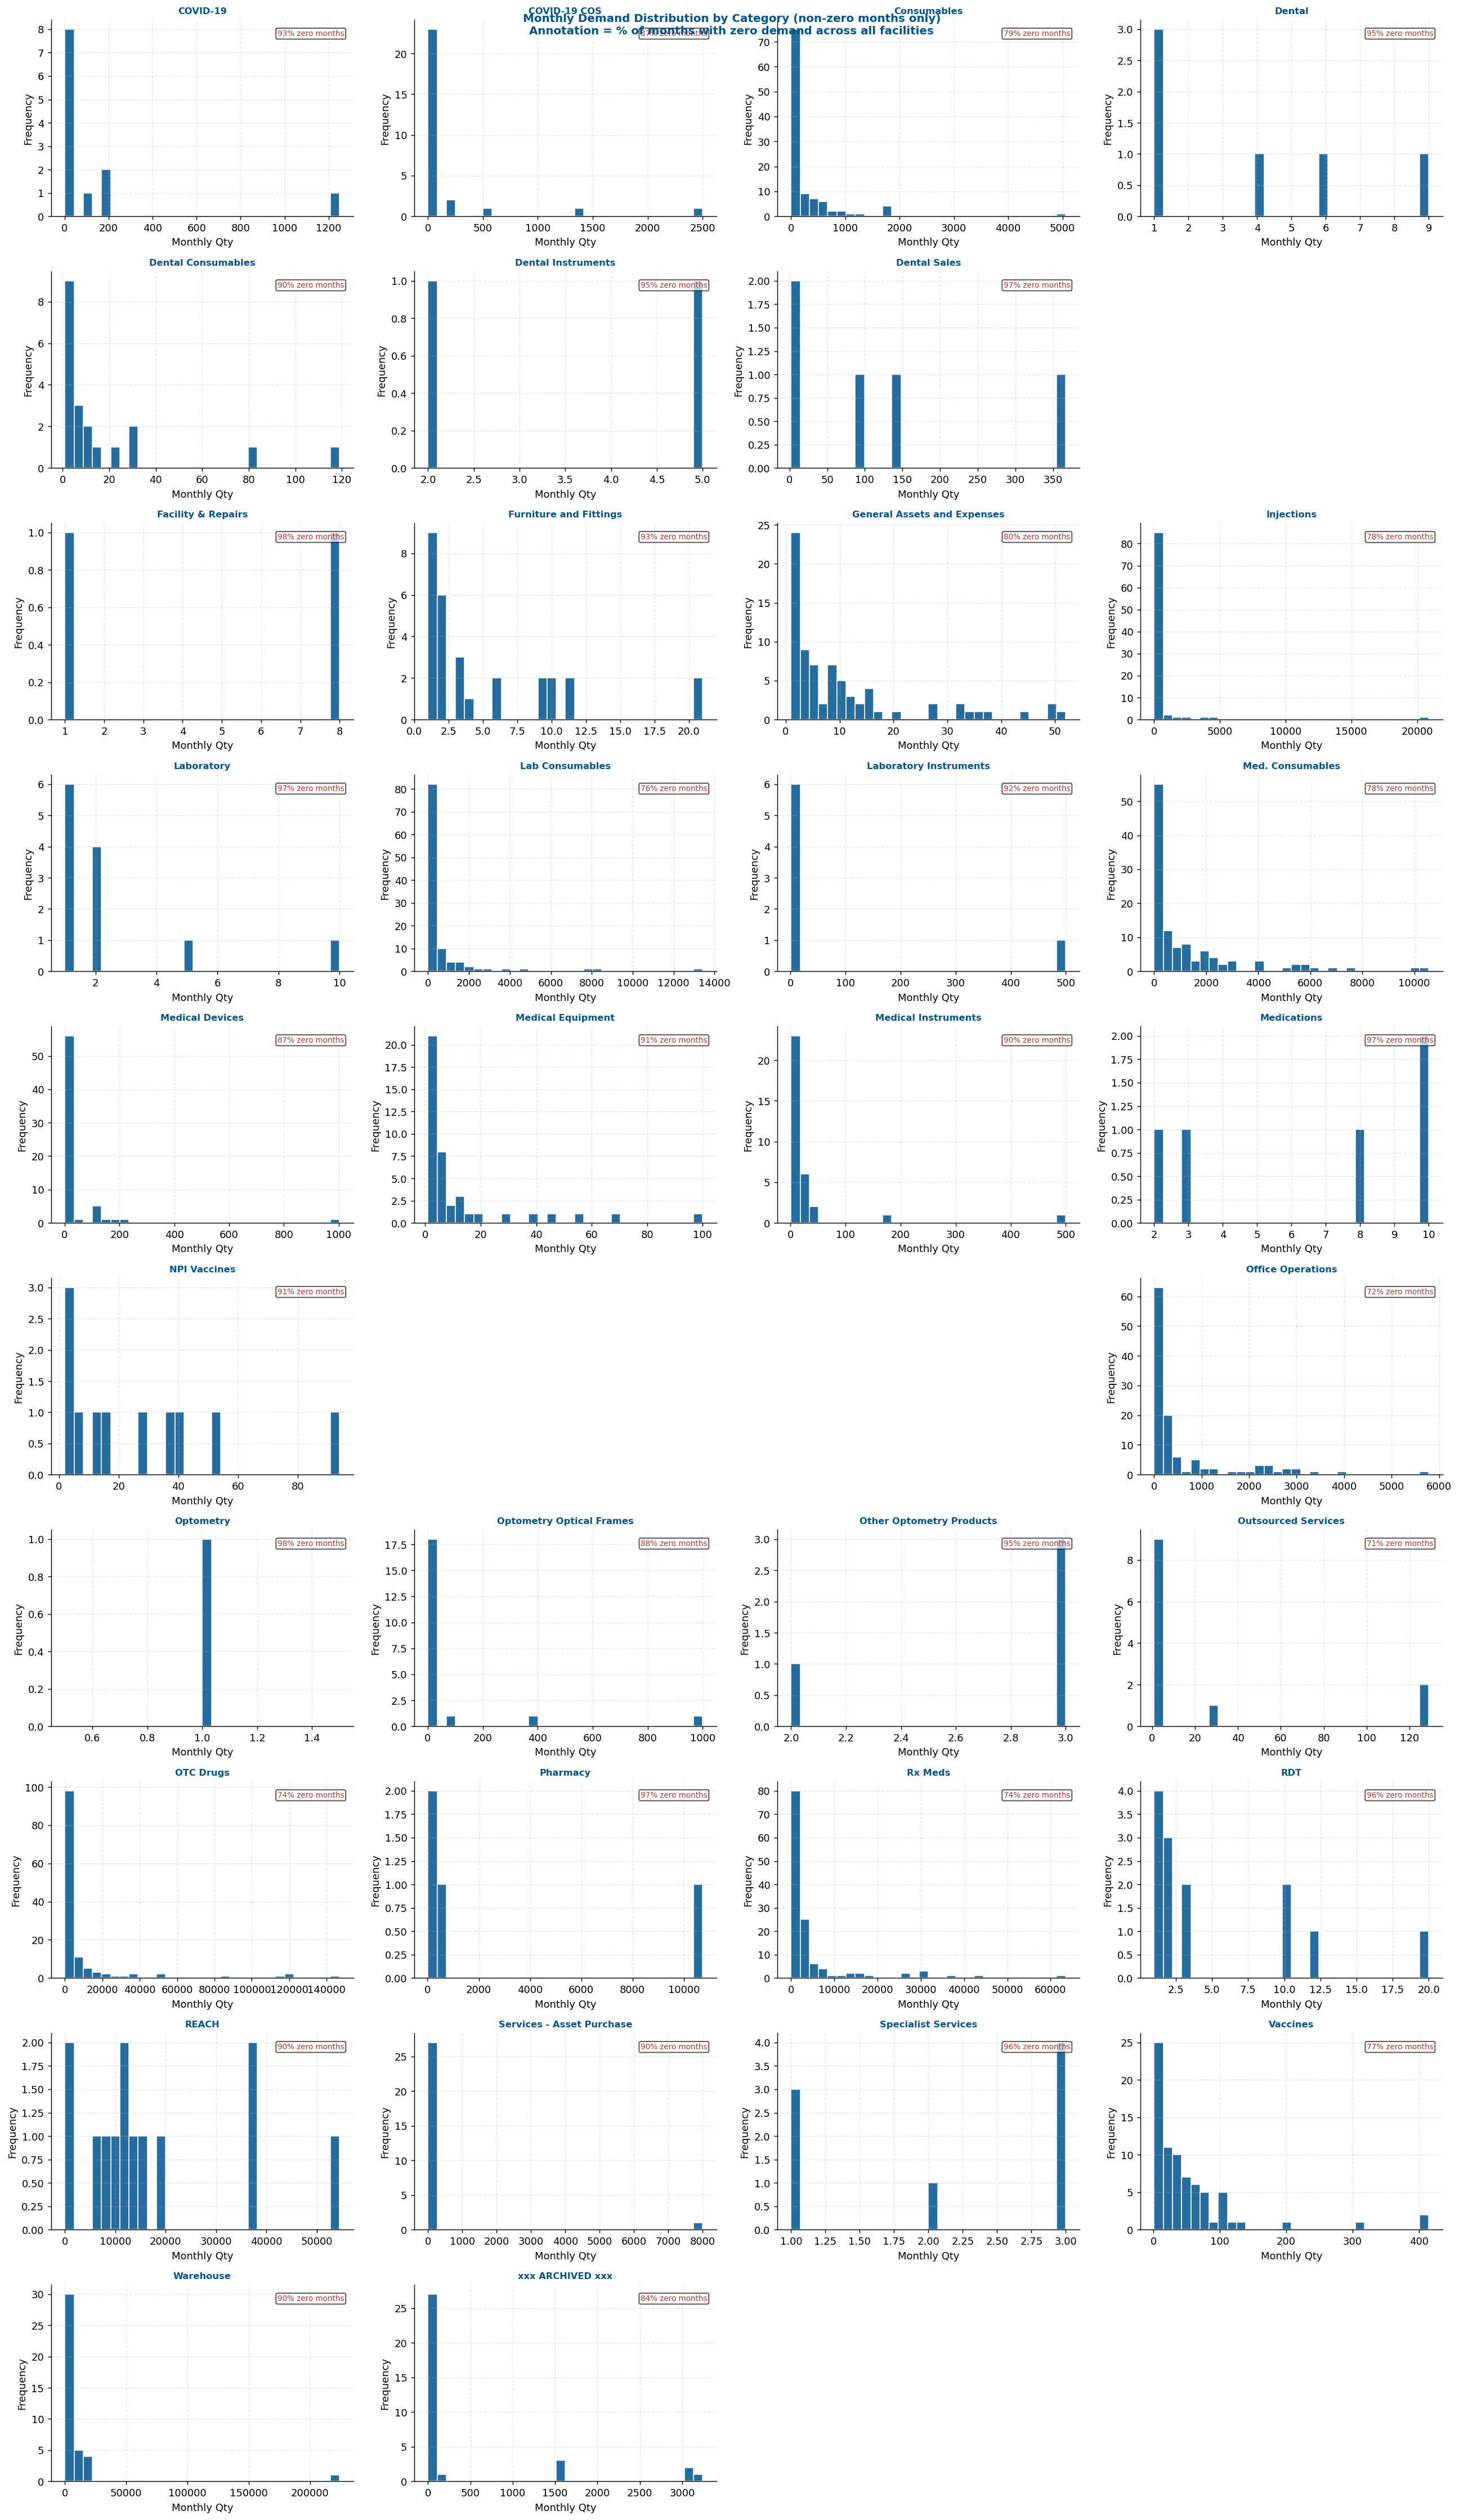

In [9]:
# â”€â”€ Monthly demand distribution per category â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
cats_in_data = df_monthly['category_name'].unique()
n_cats = len(cats_in_data)
ncols  = min(4, n_cats)
nrows  = (n_cats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for ax, cat in zip(axes_flat, sorted(cats_in_data)):
    vals = df_monthly[
        (df_monthly['category_name'] == cat) & (df_monthly['product_qty'] > 0)
    ]['product_qty']
    if len(vals) == 0:
        ax.set_visible(False)
        continue
    ax.hist(vals, bins=30, color=BLUE, edgecolor='white', alpha=0.85)
    ax.set_title(SHORT_CATS.get(cat, cat), fontsize=9, color=BLUE)
    ax.set_xlabel('Monthly Qty')
    ax.set_ylabel('Frequency')
    zero_pct = (df_monthly[df_monthly['category_name'] == cat]['product_qty'] == 0).mean() * 100
    ax.text(0.97, 0.95, f'{zero_pct:.0f}% zero months',
            transform=ax.transAxes, ha='right', va='top', fontsize=7.5,
            color=RED, bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

for ax in axes_flat[n_cats:]:
    ax.set_visible(False)

fig.suptitle(
    'Monthly Demand Distribution by Category (non-zero months only)\n'
    'Annotation = % of months with zero demand across all facilities',
    fontsize=11, fontweight='bold', color=BLUE,
)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "figures" / "dq_distribution.pdf", bbox_inches="tight")
plt.show()
